In [1]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom,crystal2cartesian
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time
import os
from queer.functions import get_rotation_matrix

In [2]:
N=100
factor = 2
kx,ky,kz = mesh_cartesian(N=[N,N,1],factor=factor).T-factor/2
K = np.array([kx,ky,kz])
K= (K.T + np.array([0,0,factor/2])).T


In [3]:
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])

In [4]:
rot_mesh = rot_mat@K

In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.tri as mtri

def _to_Nx3(points):
    A = np.asarray(points)
    return A.T if A.shape[0] == 3 else A

def plot_surface_poly(points3d, ax, alpha=1.0, facecolor=None):
    P = _to_Nx3(points3d)
    if P.shape[0] < 3:
        raise ValueError("Need at least 3 non-collinear points to form a surface.")

    C = P.mean(axis=0)
    X = P - C
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    u_axis, v_axis = Vt[0], Vt[1]
    uv = np.c_[X @ u_axis, X @ v_axis]
    tri = mtri.Triangulation(uv[:, 0], uv[:, 1])

    verts = P[tri.triangles]               # (n_tri, 3, 3)
    poly = Poly3DCollection(
        verts,
        linewidths=0.0,
        edgecolors='none',
        antialiased=False
    )
    if facecolor is not None:
        poly.set_facecolor(facecolor)
    poly.set_alpha(alpha)
    ax.add_collection3d(poly)
    return poly


In [10]:
%matplotlib widget

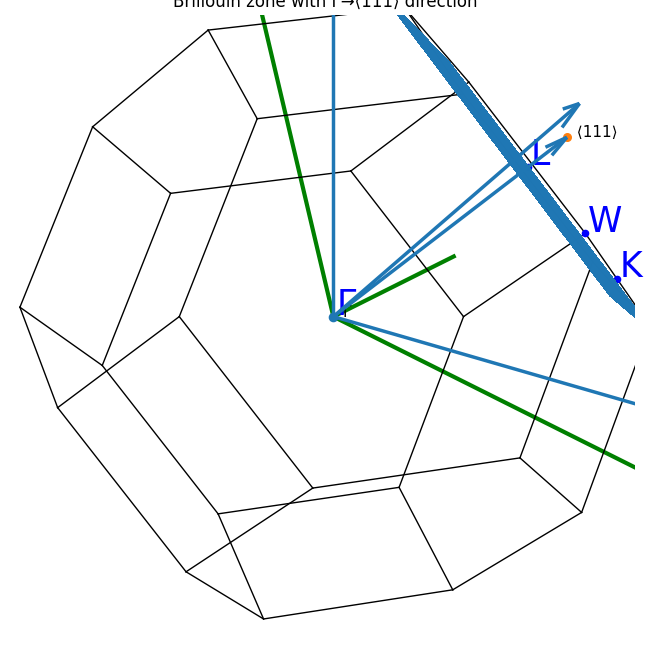

In [11]:
# Simple Brillouin zone plot with a Γ→⟨111⟩ arrow
# Requires: pymatgen, matplotlib, numpy
from pymatgen.core import Structure
from pymatgen.electronic_structure.plotter import plot_brillouin_zone
import numpy as np
import matplotlib.pyplot as plt

# --- settings ---
POSCAR_PATH = "Ag_primitive/POSCAR"   # path to your structure file
ARROW_LENGTH = None      # set a float in 1/Å to override (e.g. 1.0); None = auto

# --- load structure & reciprocal lattice (2π convention) ---
struct = Structure.from_file(POSCAR_PATH)
bz_lat = struct.lattice.reciprocal_lattice  # physics convention

# --- create figure & draw BZ ---
fig = plt.figure(figsize=(6.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
plot_brillouin_zone(
    bz_lattice=bz_lat,
    labels={"L":[1/2,1/2,1/2],"W":[1/2, 1/4, 3/4],"K":[0.375, 0.375, 3/4],r"$\Gamma$": [0, 0, 0]},
    ax=ax,
    show=False,
    tight_layout=True
)



# Create the path
# Define symmetry points and labels
labels = ['L', 'W', 'K','L']
# --- build Γ→⟨111⟩ arrow (in reciprocal Cartesian coords) ---
dir_frac = np.array([1, 1, 1])                # ⟨111⟩ in *reciprocal* fractional coords
dir_cart = bz_lat.get_cartesian_coords(dir_frac)       # to Cartesian (1/Å)
dir_unit = dir_cart / np.linalg.norm(dir_cart)

# safe default: a fraction of the shortest |b_i| so arrow stays inside the BZ
bvecs = bz_lat.matrix
default_len = 0.6 * np.min(np.linalg.norm(bvecs, axis=1))
L = default_len if ARROW_LENGTH is None else float(ARROW_LENGTH)
end = dir_unit * L

# draw arrow + points
ax.quiver(0, 0, 0, 3, 0, 0, linewidth=2.5, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, 3, 0, linewidth=2.5, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, 0, 3, linewidth=2.5, arrow_length_ratio=0.08)

ax.scatter([0], [0], [0], s=35)                 # Γ
ax.scatter([end[0]], [end[1]], [end[2]], s=30)  # arrow head
ax.text(0, 0, 0, r"  $\Gamma$", fontsize=11)
ax.text(end[0], end[1], end[2], "  ⟨111⟩", fontsize=11)

rot_shift = (rot_mesh.T+np.array([1,1,1])*3/4).T

# ax.scatter(rot_mesh[0],rot_mesh[1],rot_mesh[2])
ax.quiver(0, 0, 0, end[0], end[1], end[2], linewidth=2.5, arrow_length_ratio=0.08)

# ax.scatter(rot_shift[0],rot_shift[1],rot_shift[2])
# ax.scatter(K[0],K[1],K[2])
# triangulated_surface_from_points(inv_shift, ax, face_alpha=0.35)
plot_surface_poly(rot_shift, ax, alpha=0.9, facecolor=None)


# cosmetics
ax.set_xlabel(r"$k_x$ (1/Å)")
ax.set_ylabel(r"$k_y$ (1/Å)")
ax.set_zlabel(r"$k_z$ (1/Å)")
ax.set_box_aspect([1, 1, 1])  # equal aspect if Matplotlib ≥ 3.3
# except Exception:
#     pass
ax.set_title("Brillouin zone with Γ→⟨111⟩ direction")
plt.show()
